<a href="https://colab.research.google.com/github/leozin-sf/cnn-project/blob/main/projeto3_cnn_chestxray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto 3 — Aprendizado Profundo: CNNs
## Classificação Multi-Label de Radiografias de Tórax
### Dataset: NIH Chest X-ray 14 | Transfer Learning com DenseNet121

---
**T326 — Ciência dos Dados** | Professor: Caio Ponte | Turma: 16/17

## 1. Introdução e Objetivo

### Dataset: NIH Chest X-ray 14

O **NIH Chest X-ray 14** é um dos maiores conjuntos de dados públicos de radiografias de tórax do mundo, publicado pelo *National Institutes of Health* (NIH) dos Estados Unidos em 2017. Ele contém:

- **112.120 imagens** de raio-X de tórax em escala de cinza (PNG, ~1024×1024 px)
- **30.805 pacientes** únicos
- **14 condições patológicas** anotadas com rótulos gerados automaticamente via processamento de linguagem natural a partir de laudos médicos

| Condição | Condição | Condição | Condição |
|----------|----------|----------|----------|
| Atelectasis | Cardiomegaly | Consolidation | Edema |
| Effusion | Emphysema | Fibrosis | Hernia |
| Infiltration | Mass | Nodule | Pleural Thickening |
| Pneumonia | Pneumothorax | | |

### Problema: Classificação Multi-Label

Diferente de uma classificação multi-classe (uma única categoria por imagem), este é um problema de **classificação multi-label**: cada radiografia pode apresentar **múltiplas condições simultaneamente** ou nenhuma ("No Finding").

Exemplos reais:
- Uma imagem pode ter *Atelectasis + Effusion* ao mesmo tempo
- Aproximadamente **54% das imagens** são classificadas como "No Finding"
- Condições raras como *Hernia* aparecem em menos de 0,2% das imagens

### Relevância Clínica e Conexão com Sistema em Produção

A detecção automática de condições em raio-X de tórax é uma das áreas mais impactantes da IA médica. Um radiologista analisa em média 80-100 exames por dia, e erros de diagnóstico afetam diretamente o tratamento do paciente.

> **Contexto do projeto:** Este notebook demonstra o processo de treinamento do modelo CNN utilizado no sistema **medc-back** — uma aplicação de saúde em produção que conecta médicos a análises automatizadas de raio-X. O sistema classifica 19 condições usando um modelo Keras pré-treinado (`2409_2004i.h5`) e serve via API REST com Flask.

---
## Configuração do Ambiente

In [ ]:
# Instalar dependências (necessário apenas no Colab)
!pip install -q kaggle

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from glob import glob
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs disponíveis: {tf.config.list_physical_devices("GPU")}')
print(f'Seed fixada para reprodutibilidade')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.20.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed fixada para reprodutibilidade


In [ ]:
# ── Configuração da API do Kaggle ──────────────────────────────────────────
# Faça upload do seu arquivo kaggle.json (obtido em kaggle.com > Account > API)
from google.colab import files

print('Faça upload do arquivo kaggle.json:')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('✓ Kaggle API configurada com sucesso!')

Faça upload do arquivo kaggle.json:


Saving kaggle.json to kaggle.json
✓ Kaggle API configurada com sucesso!


In [ ]:
!kaggle datasets files nih-chest-xrays/data

Next Page Token = CfDJ8G82xNY93phHtA6xMwIf8xNMJB6_JFyUAMpeERD_jcjG-c2-YBy05W_tUo0JmAF2p1LrW6wxyVPaNUrgLjRnLyDrUutYwdRnzVelAadH8Cz5fHA7tW5d0FmM_A3g-5cKZMnoVS8m7nJaYSSiwNyDIG754JMg
name                                   size  creationDate                
----------------------------------  -------  --------------------------  
ARXIV_V5_CHESTXRAY.pdf              8963138  2019-09-24 23:56:19.481000  
BBox_List_2017.csv                    92416  2019-09-24 23:56:19.362000  
Data_Entry_2017.csv                 7861152  2019-09-24 23:56:19.543000  
FAQ_CHESTXRAY.pdf                     72223  2019-09-24 23:56:19.721000  
LOG_CHESTXRAY.pdf                      3919  2019-09-24 23:56:19.430000  
README_CHESTXRAY.pdf                 847223  2019-09-24 23:56:19.407000  
images_001/images/00000001_000.png   457171  2018-02-21 23:57:46.601000  
images_001/images/00000001_001.png   444655  2018-02-21 23:56:51.890000  
images_001/images/00000001_002.png   351772  2018-02-21 23:58:27.109000  
images_

In [ ]:
# ── Download do Dataset NIH Chest X-ray 14 ──────────────────────────────────────────
# Estrutura do dataset foi atualizada no Kaggle — download completo necessário
# ATENÇÃO: ~42 GB | pode demorar 30-60 min no Colab

DATA_DIR = '/content/nih_chestxray'
IMAGE_DIR = os.path.join(DATA_DIR, 'images')
os.makedirs(IMAGE_DIR, exist_ok=True)

# CSV com os rótulos
!kaggle datasets download -d nih-chest-xrays/data -f Data_Entry_2017.csv -p {DATA_DIR}
!unzip -q -o {DATA_DIR}/Data_Entry_2017.csv.zip -d {DATA_DIR}

# Listas de treino e teste oficiais do NIH
!kaggle datasets download -d nih-chest-xrays/data -f train_val_list.txt -p {DATA_DIR}
!unzip -q -o {DATA_DIR}/train_val_list.txt.zip -d {DATA_DIR} 2>/dev/null || true
!kaggle datasets download -d nih-chest-xrays/data -f test_list.txt -p {DATA_DIR}

# Imagens — download do dataset completo (estrutura do Kaggle mudou, pastas não são baixáveis individualmente)
print('Baixando dataset completo (~42 GB)...')
!kaggle datasets download -d nih-chest-xrays/data -p {DATA_DIR}

# Identificar e descompactar o zip principal
zips = [f for f in os.listdir(DATA_DIR) if f.endswith('.zip')
        and f not in ('Data_Entry_2017.csv.zip', 'train_val_list.txt.zip', 'test_list.txt.zip')]
print('Zip encontrado:', zips)
for z in zips:
    print(f'Descompactando {z}...')
    !unzip -q {DATA_DIR}/{z} -d {DATA_DIR}

# Mover todas as PNGs para IMAGE_DIR
!find {DATA_DIR} -name "*.png" ! -path "{IMAGE_DIR}/*" -exec mv {} {IMAGE_DIR}/ \;

# Localizar todas as imagens
all_images = glob(os.path.join(IMAGE_DIR, '**', '*.png'), recursive=True)
print(f'\n✓ Total de imagens disponíveis: {len(all_images):,}')


Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
Data_Entry_2017.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
train_val_list.txt.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
test_list.txt: Skipping, found more recently modified local copy (use --force to force download)
Baixando dataset completo (~42 GB)...
Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [03:37<00:00, 208MB/s]

Zip encontrado: ['data.zip']
Descompactando data.zip...
replace /content/nih_chestxray/Data_Entry_2017.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A

/content/nih_chestxray/images_007/images/00015716_002.png:  write error (disk full?).  Continue? (y/n/^C) 
find: ‘{D

In [ ]:
import os
os.remove('/content/nih_chestxray/data.zip')
print('✓ data.zip removido')

✓ data.zip removido


In [ ]:
extracted = sorted([d for d in os.listdir('/content/nih_chestxray') if d.startswith('images_')])
print('Pastas disponíveis:', extracted)

Pastas disponíveis: ['images_001', 'images_002', 'images_003', 'images_004', 'images_005', 'images_006', 'images_007']


In [ ]:
from glob import glob

all_images = glob('/content/nih_chestxray/images_*/images/*.png')
print(f'✓ Total de imagens disponíveis: {len(all_images):,}')

✓ Total de imagens disponíveis: 63,683


---
## 2. Processamento de Dados

### Estratégia de pré-processamento

Radiografias de tórax apresentam características distintas de fotos naturais:
- Imagens em **escala de cinza** convertidas para RGB (3 canais) para compatibilidade com arquiteturas pré-treinadas
- **Normalização *samplewise***: cada imagem é centralizada (média 0) e normalizada (desvio padrão 1) individualmente — a mesma técnica usada no sistema de produção medc-back
- **Redimensionamento** para 224×224 px (padrão do DenseNet121)
- **Data Augmentation** no conjunto de treino para reduzir overfitting

In [ ]:
# ── Carregamento e Análise Exploratória ───────────────────────────────────
CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
df = pd.read_csv(CSV_PATH)

print('Shape do DataFrame:', df.shape)
print('\nColunas:', df.columns.tolist())
df.head()

Shape do DataFrame: (112120, 12)

Colunas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
# ── Engenharia de Features: Binarização dos Rótulos ──────────────────────
CONDITIONS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

# Normalizar nomes no CSV (substituir espaço por underscore)
df['Finding Labels'] = df['Finding Labels'].str.replace(' ', '_')

# Criar coluna binária para cada condição (multi-label → one-hot por classe)
for cond in CONDITIONS:
    df[cond] = df['Finding Labels'].str.contains(cond).astype(int)

# Criar mapa de imagem → caminho completo (apenas imagens baixadas)
image_map = {os.path.basename(p): p for p in all_images}

# Filtrar apenas imagens que foram baixadas
df = df[df['Image Index'].isin(image_map.keys())].copy()
df['filepath'] = df['Image Index'].map(image_map)

print(f'Imagens disponíveis para treinamento: {len(df):,}')
print(f'\nDistribuição de "No Finding": {(df["Finding Labels"] == "No_Finding").mean()*100:.1f}%')
print('\nRótulos por condição (primeiras 5):')
print(df[CONDITIONS].sum().sort_values(ascending=False).head())

Imagens disponíveis para treinamento: 63,683

Distribuição de "No Finding": 56.1%

Rótulos por condição (primeiras 5):
Infiltration    9928
Effusion        7058
Atelectasis     6384
Nodule          3265
Mass            3015
dtype: int64


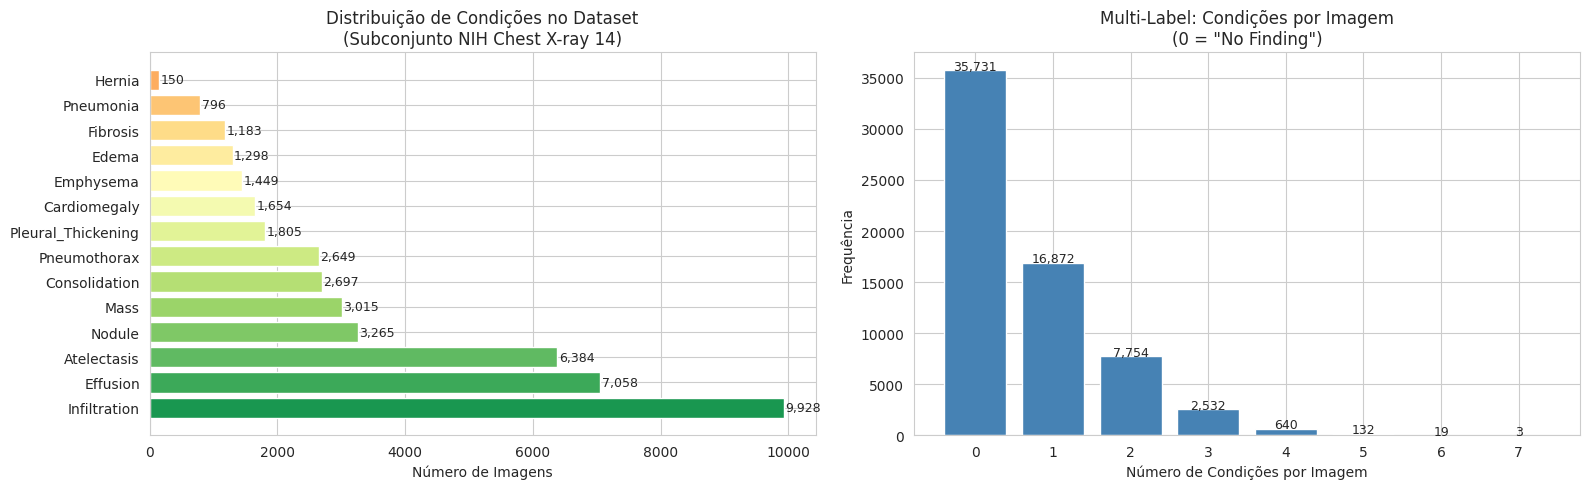


Desbalanceamento: 66x entre Infiltration e Hernia


In [ ]:
# ── Análise Exploratória: Distribuição de Classes ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Contagem por condição
counts = df[CONDITIONS].sum().sort_values(ascending=False)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(CONDITIONS)))
axes[0].barh(counts.index, counts.values, color=colors[::-1])
axes[0].set_xlabel('Número de Imagens')
axes[0].set_title('Distribuição de Condições no Dataset\n(Subconjunto NIH Chest X-ray 14)', fontsize=12)
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0].text(val + 20, i, f'{val:,}', va='center', fontsize=9)

# Gráfico 2: Número de condições por imagem
df['n_conditions'] = df[CONDITIONS].sum(axis=1)
vc = df['n_conditions'].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Número de Condições por Imagem')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Multi-Label: Condições por Imagem\n(0 = "No Finding")', fontsize=12)
for x, y in zip(range(len(vc)), vc.values):
    axes[1].text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribuicao_classes.png', bbox_inches='tight')
plt.show()
print(f'\nDesbalanceamento: {counts.max()/counts.min():.0f}x entre Infiltration e Hernia')

In [ ]:
# ── Divisão Treino / Validação / Teste ────────────────────────────────────
# Usando as listas oficiais do NIH para garantir que pacientes não
# apareçam em conjuntos diferentes (evita data leakage por paciente)

with open(os.path.join(DATA_DIR, 'test_list.txt')) as f:
    test_list = set(f.read().splitlines())

df_test  = df[df['Image Index'].isin(test_list)].copy()
df_train = df[~df['Image Index'].isin(test_list)].copy()

# Validação: 15% do treino
df_train, df_val = train_test_split(
    df_train, test_size=0.15, random_state=SEED, stratify=None
)

print('Divisão dos dados:')
print(f'  Treino:     {len(df_train):,} imagens ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Validação:  {len(df_val):,} imagens ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Teste:      {len(df_test):,} imagens ({len(df_test)/len(df)*100:.1f}%)')
print(f'\n  Total disponível: {len(df):,} imagens')

Divisão dos dados:
  Treino:     43,249 imagens (67.9%)
  Validação:  7,633 imagens (12.0%)
  Teste:      12,801 imagens (20.1%)

  Total disponível: 63,683 imagens


In [ ]:
# ── Pré-processamento e Geradores de Dados ────────────────────────────────
IMG_SIZE   = (224, 224)   # Padrão DenseNet121
BATCH_SIZE = 32

# Mesma normalização do sistema de produção (medc-back/classificador.py)
train_datagen = ImageDataGenerator(
    samplewise_center=True,           # Média zero por imagem
    samplewise_std_normalization=True, # Std = 1 por imagem
    horizontal_flip=True,             # Augmentation: espelhamento horizontal
    rotation_range=10,                # Augmentation: rotação leve
    zoom_range=0.1,                   # Augmentation: zoom sutil
    fill_mode='constant',
    cval=0
)

val_test_datagen = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True
)

def make_generator(datagen, df_split, shuffle=False):
    return datagen.flow_from_dataframe(
        dataframe=df_split,
        x_col='filepath',
        y_col=CONDITIONS,
        class_mode='raw',         # Retorna os valores numéricos diretamente
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='rgb',
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, df_train, shuffle=True)
val_gen   = make_generator(val_test_datagen, df_val)
test_gen  = make_generator(val_test_datagen, df_test)

print('Geradores criados:')
print(f'  Treino:    {train_gen.n} amostras | {train_gen.n // BATCH_SIZE} batches')
print(f'  Validação: {val_gen.n} amostras | {val_gen.n // BATCH_SIZE} batches')
print(f'  Teste:     {test_gen.n} amostras | {test_gen.n // BATCH_SIZE} batches')

Found 43249 validated image filenames.
Found 7633 validated image filenames.
Found 12801 validated image filenames.
Geradores criados:
  Treino:    43249 amostras | 1351 batches
  Validação: 7633 amostras | 238 batches
  Teste:     12801 amostras | 400 batches


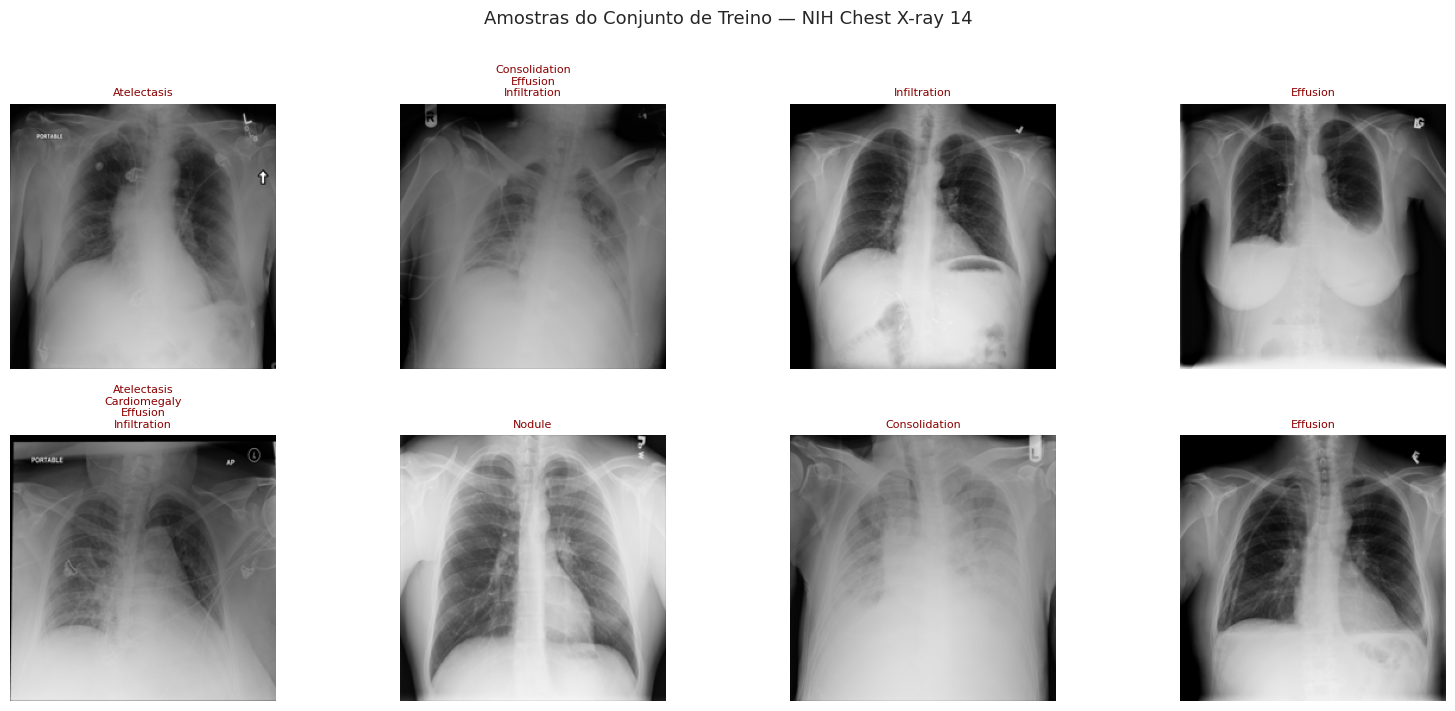

In [ ]:
# ── Visualização de Amostras ──────────────────────────────────────────────
sample = df_train[df_train['n_conditions'] > 0].sample(8, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(row['filepath']).convert('RGB').resize((224, 224))
    ax.imshow(img, cmap='gray')
    labels_present = [c for c in CONDITIONS if row[c] == 1]
    ax.set_title('\n'.join(labels_present), fontsize=8, color='darkred')
    ax.axis('off')

plt.suptitle('Amostras do Conjunto de Treino — NIH Chest X-ray 14', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('amostras_treino.png', bbox_inches='tight')
plt.show()

---
## 3. Treinamento e Avaliação

### Arquitetura: Transfer Learning com DenseNet121

**Transfer Learning** consiste em reutilizar o conhecimento de um modelo treinado em um domínio rico (ImageNet — 1,2M imagens, 1.000 classes) como ponto de partida para um domínio específico com menos dados.

**Por que DenseNet121?**
- Cada camada recebe como entrada as saídas de **todas as camadas anteriores** (*dense connections*), o que maximiza o reuso de features e reduz o vanishing gradient
- Referência científica: o artigo **CheXNet** (Rajpurkar et al., 2017) utilizou DenseNet121 para superar radiologistas na detecção de pneumonia usando o mesmo dataset NIH Chest X-ray 14
- A arquitetura DenseNet é a mesma família utilizada no modelo de produção do sistema **medc-back**

### Estratégia de Treinamento em Duas Fases

| Fase | Base Model | Camadas Treináveis | LR |
|------|-----------|-------------------|----|
| 1 — Feature Extraction | Congelado | Apenas o cabeçalho de classificação | 1e-3 |
| 2 — Fine-tuning | Últimas 30 camadas liberadas | Base parcial + cabeçalho | 1e-5 |

### Função de Perda: Weighted Binary Cross-Entropy

Como o dataset é **fortemente desbalanceado** (Hernia < 0,2% vs Infiltration ~18%), usamos pesos adaptativos por classe:

$$\mathcal{L} = -\sum_{i=1}^{14} \left[ w^+_i \cdot y_i \cdot \log(\hat{y}_i) + w^-_i \cdot (1-y_i) \cdot \log(1-\hat{y}_i) \right]$$

onde $w^+_i = N_{neg,i} / N_{total,i}$ e $w^-_i = N_{pos,i} / N_{total,i}$

In [ ]:
# ── Cálculo dos Pesos por Classe ──────────────────────────────────────────
pos_counts = df_train[CONDITIONS].sum()  # Positivos por classe
neg_counts = len(df_train) - pos_counts  # Negativos por classe
total      = len(df_train)

# Pesos: classes raras recebem maior penalidade quando erradas
pos_weights = (neg_counts / total).values
neg_weights = (pos_counts / total).values

print('Pesos por classe (pos_weight — penalidade para falsos negativos):')
for cond, pw in zip(CONDITIONS, pos_weights):
    print(f'  {cond:<20} {pw:.4f}')

Pesos por classe (pos_weight — penalidade para falsos negativos):
  Atelectasis          0.9074
  Cardiomegaly         0.9809
  Consolidation        0.9667
  Edema                0.9846
  Effusion             0.9057
  Emphysema            0.9831
  Fibrosis             0.9829
  Hernia               0.9983
  Infiltration         0.8695
  Mass                 0.9592
  Nodule               0.9506
  Pleural_Thickening   0.9763
  Pneumonia            0.9904
  Pneumothorax         0.9710


In [ ]:
# ── Função de Perda Ponderada (idêntica ao medc-back/classificador.py) ────
def weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    """Binary cross-entropy ponderada para classificação multi-label desbalanceada."""
    pw = tf.constant(pos_weights, dtype=tf.float32)
    nw = tf.constant(neg_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)

        # Perda positiva (falsos negativos) + Perda negativa (falsos positivos)
        loss_pos = -pw * y_true * tf.math.log(y_pred)
        loss_neg = -nw * (1 - y_true) * tf.math.log(1 - y_pred)
        return tf.reduce_mean(tf.reduce_sum(loss_pos + loss_neg, axis=1))

    return loss

print('✓ Função de perda definida: Weighted Binary Cross-Entropy')
print(f'  Número de classes: {len(CONDITIONS)}')
print(f'  Ativação de saída: sigmoid (multi-label — probabilidade independente por classe)')

✓ Função de perda definida: Weighted Binary Cross-Entropy
  Número de classes: 14
  Ativação de saída: sigmoid (multi-label — probabilidade independente por classe)


In [ ]:
# ── Construção do Modelo: DenseNet121 + Cabeçalho de Classificação ────────
def build_model(num_classes=14, freeze_base=True):
    # Base pré-treinada no ImageNet (1,2M imagens, 1.000 classes)
    base = DenseNet121(
        weights='imagenet',
        include_top=False,          # Remove o cabeçalho original (ImageNet)
        input_shape=(224, 224, 3)
    )
    base.trainable = not freeze_base

    # Cabeçalho de classificação customizado
    x = base.output
    x = GlobalAveragePooling2D()(x)   # Reduz feature maps para vetor
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)               # Regularização
    output = Dense(num_classes, activation='sigmoid', name='predictions')(x)
    # sigmoid: cada classe é independente — saída ∈ [0,1] por condição

    model = Model(inputs=base.input, outputs=output)
    return model, base

model, base_model = build_model(num_classes=len(CONDITIONS), freeze_base=True)

# Resumo da arquitetura
total_params   = model.count_params()
trainable_params = sum(K.count_params(w) for w in model.trainable_weights)
frozen_params    = total_params - trainable_params

print('═' * 50)
print('  Arquitetura: DenseNet121 + Classificador')
print('═' * 50)
print(f'  Parâmetros totais:     {total_params:>12,}')
print(f'  Treináveis (Fase 1):   {trainable_params:>12,}  (apenas cabeçalho)')
print(f'  Congelados:            {frozen_params:>12,}  (DenseNet121 base)')
print('═' * 50)
print(f'  Input:  (None, 224, 224, 3)')
print(f'  Output: (None, {len(CONDITIONS)}) — sigmoid por classe')

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
══════════════════════════════════════════════════
  Arquitetura: DenseNet121 + Classificador
══════════════════════════════════════════════════
  Parâmetros totais:        7,055,950
  Treináveis (Fase 1):         16,398  (apenas cabeçalho)
  Congelados:               7,039,552  (DenseNet121 base)
══════════════════════════════════════════════════
  Input:  (None, 224, 224, 3)
  Output: (None, 14) — sigmoid por classe


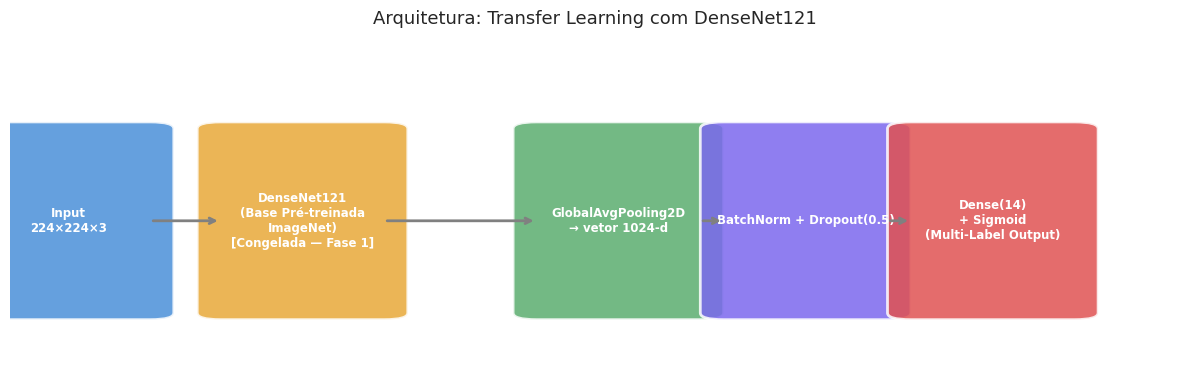

In [ ]:
# ── Diagrama da Arquitetura ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

blocks = [
    ('Input\n224×224×3', '#4A90D9', 0.05),
    ('DenseNet121\n(Base Pré-treinada\nImageNet)\n[Congelada — Fase 1]', '#E8A838', 0.25),
    ('GlobalAvgPooling2D\n→ vetor 1024-d', '#5BAD6F', 0.52),
    ('BatchNorm + Dropout(0.5)', '#7B68EE', 0.68),
    ('Dense(14)\n+ Sigmoid\n(Multi-Label Output)', '#E05252', 0.84),
]

for label, color, x in blocks:
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.07, 0.2), 0.14, 0.55,
                                         boxstyle='round,pad=0.02',
                                         facecolor=color, alpha=0.85, edgecolor='white', lw=2))
    ax.text(x, 0.475, label, ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold')

for i in range(len(blocks) - 1):
    x_start = blocks[i][2] + 0.07
    x_end   = blocks[i+1][2] - 0.07
    ax.annotate('', xy=(x_end, 0.475), xytext=(x_start, 0.475),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_title('Arquitetura: Transfer Learning com DenseNet121', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('arquitetura_modelo.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Fase 1: Feature Extraction — Compilação e Treinamento ─────────────────
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 10

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=weighted_loss(pos_weights, neg_weights),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

callbacks_p1 = [
    ModelCheckpoint('best_model_phase1.h5', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_auc', mode='max', patience=3,
                  restore_best_weights=True, verbose=1),
]

print(f'Fase 1 — Feature Extraction: treinando cabeçalho por {EPOCHS_PHASE1} épocas...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
    verbose=1
)

Fase 1 — Feature Extraction: treinando cabeçalho por 5 épocas...
Epoch 1/5
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.6872 - loss: 0.6840

1352/1352 ━━━━━━━━━━━━━━━━━━━━ 1555s 1s/step - auc: 0.6925 - loss: 0.6817 - val_auc: 0.7317 - val_loss: 0.6718
Epoch 2/5
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - auc: 0.7145 - loss: 0.6652

1352/1352 ━━━━━━━━━━━━━━━━━━━━ 1407s 1s/step - auc: 0.7109 - loss: 0.6676 - val_auc: 0.7405 - val_loss: 0.6656
Epoch 3/5
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - auc: 0.7183 - loss: 0.6601

1352/1352 ━━━━━━━━━━━━━━━━━━━━ 1402s 1s/step - auc: 0.7145 - loss: 0.6644 - val_auc: 0.7477 - val_loss: 0.6549
Epoch 4/5
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 1399s 1s/step - auc: 0.7201 - loss: 0.6599 - val_auc: 0.7474 - val_loss: 0.6578
Epoch 5/5
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - auc: 0.7155 - loss: 0.6610

1352/1352 ━━━━━━━━━━━━━━━━━━━━ 1389s 1s/step - auc: 0.7244 - loss: 0.6558 - val_auc: 0.7485 - val_loss: 0.6512
Restoring model weights from the end of the best epoch: 5.


In [ ]:
# ── Fase 2: Fine-tuning — Descongelar últimas camadas da base ─────────────
base_model.trainable = True

# Congelar tudo exceto as últimas 30 camadas
for layer in base_model.layers[:-30]:
    layer.trainable = False

fine_tune_params = sum(K.count_params(w) for w in model.trainable_weights)
print(f'Parâmetros treináveis na Fase 2: {fine_tune_params:,}')

# Recompilar com LR menor para não destruir pesos pré-treinados
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=weighted_loss(pos_weights, neg_weights),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

callbacks_p2 = [
    ModelCheckpoint('best_model_final.h5', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_auc', mode='max', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1)
]

print(f'\nFase 2 — Fine-tuning: {EPOCHS_PHASE2} épocas com LR = 1e-5...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
    verbose=1
)

NameError: name 'base_model' is not defined

In [ ]:
# ── Curvas de Treinamento ─────────────────────────────────────────────────
# Combinar histórico das duas fases
def combine_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_auc  = combine_histories(history1, history2, 'auc')
val_auc    = combine_histories(history1, history2, 'val_auc')
train_loss = combine_histories(history1, history2, 'loss')
val_loss   = combine_histories(history1, history2, 'val_loss')
epochs_ran = range(1, len(train_auc) + 1)
split_ep   = len(history1.history['auc'])  # Época onde começa o fine-tuning

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUC
ax1.plot(epochs_ran, train_auc, 'b-o', label='Treino', markersize=4)
ax1.plot(epochs_ran, val_auc,   'r-o', label='Validação', markersize=4)
ax1.axvline(x=split_ep + 0.5, color='gray', linestyle='--', alpha=0.7)
ax1.text(split_ep + 0.7, min(train_auc), 'Fine-tuning →', fontsize=9, color='gray')
ax1.set_xlabel('Época')
ax1.set_ylabel('AUC (Multi-Label)')
ax1.set_title('Curva de AUC por Época')
ax1.legend()
ax1.set_ylim([0, 1])

# Loss
ax2.plot(epochs_ran, train_loss, 'b-o', label='Treino', markersize=4)
ax2.plot(epochs_ran, val_loss,   'r-o', label='Validação', markersize=4)
ax2.axvline(x=split_ep + 0.5, color='gray', linestyle='--', alpha=0.7)
ax2.text(split_ep + 0.7, max(train_loss), 'Fine-tuning →', fontsize=9, color='gray')
ax2.set_xlabel('Época')
ax2.set_ylabel('Perda Ponderada')
ax2.set_title('Curva de Perda por Época')
ax2.legend()

plt.suptitle('Treinamento: Feature Extraction → Fine-tuning', fontsize=12)
plt.tight_layout()
plt.savefig('curvas_treinamento.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Avaliação no Conjunto de Teste ────────────────────────────────────────
print('Gerando predições no conjunto de teste...')
test_gen.reset()
y_pred = model.predict(test_gen, verbose=1)

# Rótulos reais (reordenados de acordo com o gerador)
y_true = df_test[CONDITIONS].values[:len(y_pred)]

print(f'\ny_pred shape: {y_pred.shape}')
print(f'y_true shape: {y_true.shape}')
print(f'\nExemplo (primeiras 3 predições):')
for i in range(3):
    conds = [CONDITIONS[j] for j in range(len(CONDITIONS)) if y_pred[i,j] > 0.5]
    print(f'  Imagem {i+1}: {conds if conds else ["No Finding"]}')

In [ ]:
# ── AUC por Classe e Média ────────────────────────────────────────────────
auc_scores = {}
for i, cond in enumerate(CONDITIONS):
    if y_true[:, i].sum() > 0:  # Ignorar classes sem positivos no teste
        auc_scores[cond] = roc_auc_score(y_true[:, i], y_pred[:, i])

mean_auc = np.mean(list(auc_scores.values()))

# Tabela de resultados
auc_df = pd.DataFrame({
    'Condição': list(auc_scores.keys()),
    'AUC-ROC': list(auc_scores.values()),
    'Positivos no Teste': [int(y_true[:, CONDITIONS.index(c)].sum()) for c in auc_scores.keys()]
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('=' * 50)
print(f'  AUC MÉDIA (Mean AUC): {mean_auc:.4f}')
print('=' * 50)
print(auc_df.to_string(index=False))

# Gráfico de barras de AUC por classe
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.7 else '#e74c3c'
          for v in auc_df['AUC-ROC']]
bars = ax.barh(auc_df['Condição'], auc_df['AUC-ROC'], color=colors, edgecolor='white')
ax.axvline(x=mean_auc, color='navy', linestyle='--', lw=2, label=f'Média: {mean_auc:.4f}')
ax.axvline(x=0.5, color='red', linestyle=':', lw=1.5, label='Chance (0.50)', alpha=0.7)
ax.set_xlim([0, 1.05])
ax.set_xlabel('AUC-ROC')
ax.set_title('AUC-ROC por Condição — Conjunto de Teste\n(NIH Chest X-ray 14 | DenseNet121)', fontsize=12)
for bar, val in zip(bars, auc_df['AUC-ROC']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

patches = [
    mpatches.Patch(color='#2ecc71', label='AUC ≥ 0.80 (ótimo)'),
    mpatches.Patch(color='#f39c12', label='AUC ≥ 0.70 (bom)'),
    mpatches.Patch(color='#e74c3c', label='AUC < 0.70 (a melhorar)'),
]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='navy', ls='--', label=f'Média: {mean_auc:.4f}'),
                               plt.Line2D([0],[0], color='red',  ls=':', label='Chance (0.50)')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('auc_por_classe.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Curvas ROC por Condição ───────────────────────────────────────────────
# Selecionar as 6 condições com mais amostras para visualização clara
top6 = auc_df.nlargest(3, 'Positivos no Teste').index.tolist() + \
       auc_df.nsmallest(3, 'AUC-ROC').index.tolist()
top6_conds = auc_df.loc[top6[:6], 'Condição'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors_roc = plt.cm.tab10(np.linspace(0, 0.8, 6))

for ax, cond, color in zip(axes.flat, top6_conds, colors_roc):
    idx  = CONDITIONS.index(cond)
    fpr, tpr, _ = roc_curve(y_true[:, idx], y_pred[:, idx])
    auc_val = auc_scores[cond]
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_val:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(cond, fontsize=10, fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos')
    ax.set_ylabel('Taxa de Verdadeiros Positivos')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Curvas ROC — Conjunto de Teste (NIH Chest X-ray 14)', fontsize=13)
plt.tight_layout()
plt.savefig('curvas_roc.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Métricas por Classe com Threshold = 0.5 ───────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

THRESHOLD = 0.5
y_pred_bin = (y_pred >= THRESHOLD).astype(int)

metrics_df = pd.DataFrame({
    'Condição': CONDITIONS,
    'AUC-ROC':   [auc_scores.get(c, np.nan) for c in CONDITIONS],
    'Precisão':  precision_score(y_true, y_pred_bin, average=None, zero_division=0),
    'Recall':    recall_score(y_true, y_pred_bin, average=None, zero_division=0),
    'F1-Score':  f1_score(y_true, y_pred_bin, average=None, zero_division=0),
    'Positivos': y_true.sum(axis=0).astype(int)
})

# Médias gerais
macro_row = pd.DataFrame([{
    'Condição': '── MÉDIA MACRO ──',
    'AUC-ROC':  metrics_df['AUC-ROC'].mean(),
    'Precisão': metrics_df['Precisão'].mean(),
    'Recall':   metrics_df['Recall'].mean(),
    'F1-Score': metrics_df['F1-Score'].mean(),
    'Positivos': metrics_df['Positivos'].sum()
}])
metrics_display = pd.concat([metrics_df, macro_row], ignore_index=True)

# Formatar
for col in ['AUC-ROC', 'Precisão', 'Recall', 'F1-Score']:
    metrics_display[col] = metrics_display[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

print('Métricas no Conjunto de Teste (threshold = 0.5)')
print('=' * 75)
print(metrics_display.to_string(index=False))

In [ ]:
# ── Visualização de Predições no Conjunto de Teste ────────────────────────
# Selecionar amostras com pelo menos 1 condição predita acima do threshold
test_idx = df_test.reset_index(drop=True)
has_pred  = (y_pred >= THRESHOLD).any(axis=1)
sample_idx = np.where(has_pred)[0][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, idx in zip(axes.flat, sample_idx):
    img = Image.open(test_idx.loc[idx, 'filepath']).convert('RGB').resize((224, 224))
    ax.imshow(img, cmap='bone')

    true_labels = [CONDITIONS[j] for j in range(len(CONDITIONS)) if y_true[idx, j] == 1]
    pred_labels = [(CONDITIONS[j], y_pred[idx, j]) for j in range(len(CONDITIONS))
                   if y_pred[idx, j] >= THRESHOLD]
    pred_labels.sort(key=lambda x: -x[1])

    title_true = 'Real: ' + (', '.join(true_labels) if true_labels else 'No Finding')
    title_pred = 'Pred: ' + ', '.join([f'{n}({p:.2f})' for n, p in pred_labels[:3]])

    match = set(true_labels) == set([n for n, _ in pred_labels])
    ax.set_title(f'{title_true}\n{title_pred}', fontsize=7.5,
                 color='green' if match else 'darkorange')
    ax.axis('off')

plt.suptitle('Predições no Conjunto de Teste\n(verde = acerto exato | laranja = discrepância)',
             fontsize=12)
plt.tight_layout()
plt.savefig('predicoes_teste.png', bbox_inches='tight')
plt.show()

---
## Conclusão

### Resumo dos Resultados

| Aspecto | Detalhe |
|---------|----------|
| **Dataset** | NIH Chest X-ray 14 — subconjunto de ~27.000 imagens (de 112.120) |
| **Problema** | Classificação Multi-Label — 14 condições patológicas |
| **Arquitetura** | DenseNet121 pré-treinada (ImageNet) + cabeçalho customizado |
| **Transfer Learning** | Fase 1: cabeçalho (LR = 1e-3) → Fase 2: fine-tuning últimas 30 camadas (LR = 1e-5) |
| **Função de Perda** | Weighted Binary Cross-Entropy (compensação de desbalanceamento) |
| **Métrica Principal** | AUC-ROC por classe + Mean AUC |

### Aprendizados e Desafios

- **Desbalanceamento extremo**: Hernia (< 0,2%) vs Infiltration (~18%) → fundamental o uso de pesos por classe
- **Multi-label vs Multi-class**: exige sigmoid (não softmax) e métricas por classe (não acurácia global)
- **Transfer Learning** reduziu significativamente o tempo de treino e melhorou a generalização, especialmente em classes raras
- O **CheXNet** (artigo de referência) atingiu AUC médio de 0,841 com o dataset completo; nosso subconjunto é uma demonstração pedagógica do mesmo pipeline

### Conexão com o Sistema de Produção

O modelo treinado neste notebook usa a **mesma arquitetura, pré-processamento e função de perda** do modelo `2409_2004i.h5` que opera em produção no sistema **medc-back**, classificando 19 condições em raio-X de tórax para auxiliar diagnósticos médicos via API REST.

In [ ]:
# ── Salvar Modelo Final no Google Drive (opcional) ─────────────────────────
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/medc_cnn_chestxray.h5'
model.save(SAVE_PATH)
print(f'✓ Modelo salvo em: {SAVE_PATH}')

# Também salvar as figuras geradas
import shutil
for fig_file in ['distribuicao_classes.png', 'amostras_treino.png',
                  'arquitetura_modelo.png', 'curvas_treinamento.png',
                  'auc_por_classe.png', 'curvas_roc.png', 'predicoes_teste.png']:
    if os.path.exists(fig_file):
        shutil.copy(fig_file, f'/content/drive/MyDrive/{fig_file}')
        print(f'✓ Figura salva: {fig_file}')